In [1]:
from origami_jsynth.data import load_jsonl

# Make sure the data files exist, by running `origami-jsynth data --dataset adult` in the terminal.
adult_train = load_jsonl("../results/adult/data/train.jsonl")
adult_test = load_jsonl("../results/adult/data/test.jsonl")

print(f"Number of training examples: {len(adult_train)}")
print(f"Number of test examples: {len(adult_test)}")

Number of training examples: 32561
Number of test examples: 16281


In [2]:
import yaml
from origami import DataConfig, InferenceConfig, ModelConfig, OrigamiConfig, OrigamiPipeline, TrainingConfig
from origami.training import TrainerCallback

# Load best config from yaml
with open("../configs/adult.yaml") as f:
    config = yaml.safe_load(f)


# evaluate val_loss every epoch on full test set
def make_config(shuffle_keys=True):
    return OrigamiConfig(
        data=DataConfig(**config["data"]),
        model=ModelConfig(**config["model"]),
        training=TrainingConfig(
            **(
                config["training"]
                | {"shuffle_keys": shuffle_keys, "learning_rate": 1e-3, "eval_epochs": 1, "eval_sample_size": None}
            )
        ),
        inference=InferenceConfig(**config["inference"]),
    )


config_shuffled = make_config(shuffle_keys=True)
config_unshuffled = make_config(shuffle_keys=False)


In [11]:
from origami.training import NotebookCallback


class HistoryCallback(TrainerCallback):
    """Records per-epoch train and val loss."""

    def __init__(self):
        self.train_losses = []
        self.val_losses = []

    def on_epoch_end(self, trainer, state, epoch_stats):
        self.train_losses.append(epoch_stats.loss)

    def on_evaluate(self, trainer, state, metrics):
        if "val_loss" in metrics:
            self.val_losses.append(metrics["val_loss"])


# Train model with key shuffling
history_shuffled = HistoryCallback()
pipeline_shuffled = OrigamiPipeline(config_shuffled)
pipeline_shuffled.fit(
    data=adult_train,
    eval_data=adult_test,
    epochs=200,
    callbacks=[NotebookCallback(metrics=["loss", "val_loss"]), history_shuffled],
)

# Train model without key shuffling
history_unshuffled = HistoryCallback()
pipeline_unshuffled = OrigamiPipeline(config_unshuffled)
pipeline_unshuffled.fit(
    data=adult_train,
    eval_data=adult_test,
    epochs=200,
    callbacks=[NotebookCallback(metrics=["loss", "val_loss"]), history_unshuffled],
)

OrigamiPipeline(numeric_mode='scale', fitted)

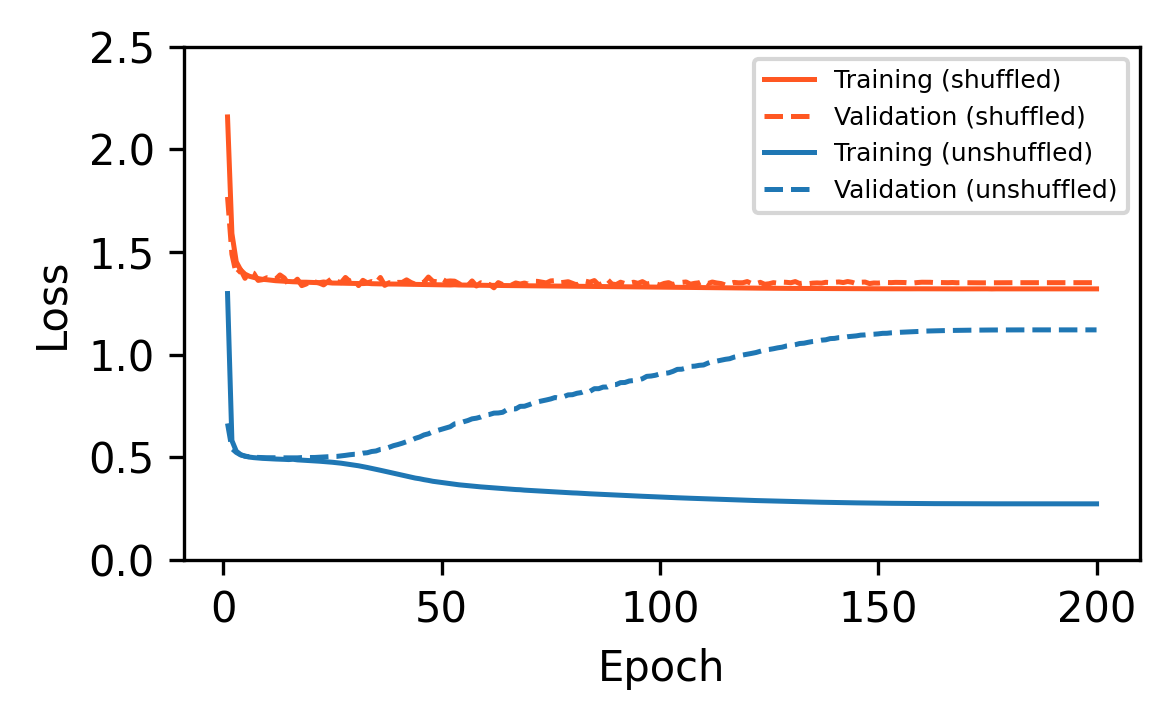

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 2.5))

for history, shuffle_val, label_suffix in [
    (history_shuffled, True, "shuffled"),
    (history_unshuffled, False, "unshuffled"),
]:
    color = "#FF5722" if shuffle_val else "C0"
    epochs_train = range(1, len(history.train_losses) + 1)
    epochs_val = range(1, len(history.val_losses) + 1)

    ax.plot(
        epochs_train,
        history.train_losses,
        color=color,
        linestyle="-",
        label=f"Training ({label_suffix})",
        linewidth=1.2,
    )
    ax.plot(
        epochs_val, history.val_losses, color=color, linestyle="--", label=f"Validation ({label_suffix})", linewidth=1.2
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_ylim(0, 2.5)
ax.legend(fontsize=6)
fig.set_dpi(300)
fig.tight_layout()
fig.savefig("shuffle_keys_ablation.pdf", bbox_inches="tight")
fig.savefig("shuffle_keys_ablation.png", bbox_inches="tight")